# Phase 4: Generation and Evaluation
## SVG Scaling Laws - CS-GY 6923

**Steps:**
1. Mount Drive & clone/pull repo
2. Install dependencies (incl. cairosvg system libs)
3. Symlink `outputs/` to Drive
4. Verify the SP XL checkpoint and the tokenizer are present
5. Generate samples (script 10)
6. Evaluate samples + test perplexity (script 11)
7. Plot sample figures (script 12)
8. Display the metrics table inline

---
## Cell 0: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/svg-scaling-laws'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'Drive mounted. Project dir: {DRIVE_DIR}')

Mounted at /content/drive
Drive mounted. Project dir: /content/drive/MyDrive/svg-scaling-laws


---
## Cell 1: Clone / Pull Repository

In [ ]:
REPO_URL = 'https://github.com/taahamohsin/ml-extra-credit-project'
REPO_DIR = '/content/svg-scaling-laws'

import os
if os.path.exists(REPO_DIR):
    print('Repo already exists, pulling latest ...')
    !cd {REPO_DIR} && git pull
else:
    print('Cloning repo ...')
    !git clone {REPO_URL} {REPO_DIR}

%cd {REPO_DIR}
print(f'Working directory: {os.getcwd()}')

Cloning repo ...
Cloning into '/content/svg-scaling-laws'...
remote: Enumerating objects: 248, done.
remote: Counting objects: 100% (248/248), done.
remote: Compressing objects: 100% (167/167), done.
remote: Total 248 (delta 149), reused 174 (delta 75), pack-reused 0 (from 0)
Receiving objects: 100% (248/248), 1.41 MiB | 4.64 MiB/s, done.
Resolving deltas: 100% (149/149), done.
/content/svg-scaling-laws
Working directory: /content/svg-scaling-laws


---
## Cell 2: Install Dependencies
`cairosvg` needs Cairo system libraries on Colab.

In [ ]:
# System packages required by cairosvg (Colab usually has these but be safe)
!apt-get -qq install -y libcairo2 libpango-1.0-0 libpangocairo-1.0-0 > /dev/null 2>&1 || true

!pip install -q -r requirements.txt
!pip install -q cairosvg
print('Dependencies installed.')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 8.8 MB/s eta 0:00:00
Dependencies installed.


---
## Cell 3: Symlink `outputs/` → Drive

In [ ]:
import os, sys, shutil

REPO_DIR      = '/content/svg-scaling-laws'
DRIVE_OUTPUTS = '/content/drive/MyDrive/svg-scaling-laws/outputs'
LOCAL_OUTPUTS = os.path.join(REPO_DIR, 'outputs')

os.makedirs(DRIVE_OUTPUTS, exist_ok=True)

if os.path.islink(LOCAL_OUTPUTS):
    os.unlink(LOCAL_OUTPUTS)
elif os.path.exists(LOCAL_OUTPUTS):
    shutil.rmtree(LOCAL_OUTPUTS)

os.symlink(DRIVE_OUTPUTS, LOCAL_OUTPUTS)
print(f'Symlink: {LOCAL_OUTPUTS} -> {DRIVE_OUTPUTS}')

for d in ['logs', 'plots', 'samples', 'samples/unconditional', 'samples/prefix',
          'samples/rendered', 'samples/rendered/unconditional', 'samples/rendered/prefix']:
    os.makedirs(os.path.join(DRIVE_OUTPUTS, d), exist_ok=True)

sys.path.insert(0, REPO_DIR)
print('Path configured.')

Symlink: /content/svg-scaling-laws/outputs -> /content/drive/MyDrive/svg-scaling-laws/outputs
Path configured.


---
## Cell 4: Verify Checkpoint & Tokenizer

---
## Cell 4b: Extended Training — 3 More Epochs from XL Best
Runs `scripts/13_extend_xl.py`. Loads weights from `xl/best.pt`, resets
the cosine schedule, trains for 3 additional epochs (~5964 steps at
batch=32, seq=1024), and saves to `outputs/checkpoints/xl_extended/best.pt`.

**Skip this cell if `xl_extended/best.pt` already exists on Drive.**

In [ ]:
import os

EXT_CKPT = 'outputs/checkpoints/xl_extended/best.pt'

if os.path.exists(EXT_CKPT):
    sz = os.path.getsize(EXT_CKPT) / 1e6
    print(f'Extended checkpoint already exists ({sz:.0f} MB) — skipping training.')
else:
    print('Training extended model (3 extra epochs) ...')
    !python scripts/13_extend_xl.py \
        --source_checkpoint outputs/checkpoints/xl/best.pt \
        --extra_epochs 3 \
        --lr 3e-4 \
        --grad_accum 2

import torch
if os.path.exists(EXT_CKPT):
    ckpt = torch.load(EXT_CKPT, map_location='cpu', weights_only=False)
    print(f'\nExtended checkpoint summary:')
    print(f'  step          = {ckpt.get("step", "?")}')
    print(f'  best_val_loss = {ckpt.get("best_val_loss", float("nan")):.4f}')


In [ ]:
import os
import torch

CKPT_PATH      = 'outputs/checkpoints/xl/best.pt'
TOKENIZER_PATH = 'outputs/tokenizer/tokenizer.json'
TEST_BIN       = 'outputs/data/binary/test.bin'

for label, p in [('checkpoint', CKPT_PATH),
                 ('tokenizer',  TOKENIZER_PATH),
                 ('test bin',   TEST_BIN)]:
    exists = os.path.exists(p)
    sz = os.path.getsize(p) / 1e6 if exists else 0
    print(f'  {label:<11} {p}  exists={exists}  size={sz:.1f} MB')

if not os.path.exists(CKPT_PATH):
    raise FileNotFoundError(
        f'Best XL checkpoint missing at {CKPT_PATH}. '
        'Phase 2 must be complete first.')

ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
print('\nCheckpoint summary:')
print(f'  step           = {ckpt.get("step", "?")}')
print(f'  best_val_loss  = {ckpt.get("best_val_loss", float("nan")):.4f}')
print(f'  config         = {ckpt["config"]}')

  checkpoint  outputs/checkpoints/xl/best.pt  exists=True  size=1118.4 MB
  tokenizer   outputs/tokenizer/tokenizer.json  exists=True  size=0.4 MB
  test bin    outputs/data/binary/test.bin  exists=True  size=2.7 MB

Checkpoint summary:
  step           = 1988
  best_val_loss  = 3.1074
  config         = ModelConfig(vocab_size=4096, d_model=768, n_layers=12, n_heads=12, d_ff=3072, max_seq_len=1024, dropout=0.0)


!python scripts/10_generate_samples.py \
    --checkpoint outputs/checkpoints/xl_extended/best.pt \
    --tokenizer_dir outputs/tokenizer \
    --out_dir outputs/samples \
    --n_uncond 15 \
    --max_new_tokens 1024 \
    --top_k 50 \
    --top_p 0.95 \
    --uncond_prompt '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" height="200px" width="200px"><path fill="none" stroke="black" d="'


In [ ]:
!python scripts/10_generate_samples.py \
    --checkpoint outputs/checkpoints/xl/best.pt \
    --tokenizer_dir outputs/tokenizer \
    --out_dir outputs/samples \
    --n_uncond 15 \
    --max_new_tokens 1024 \
    --top_k 50 \
    --top_p 0.95 \
    --uncond_prompt '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" height="200px" width="200px"><path fill="none" stroke="black" d="'


Device: cuda
Loaded checkpoint: /content/svg-scaling-laws/outputs/checkpoints/xl/best.pt
  Non-emb params: 85,056,000
  Step:           1988
  Best val loss:  3.1074

=== Unconditional generation (5 per temperature) ===
  [1/15] t=0.5  tokens=1030  uncond_t0.5_00.svg
  [2/15] t=0.5  tokens=  46  uncond_t0.5_01.svg
  [3/15] t=0.5  tokens=1030  uncond_t0.5_02.svg
  [4/15] t=0.5  tokens=1030  uncond_t0.5_03.svg
  [5/15] t=0.5  tokens= 323  uncond_t0.5_04.svg
  [6/15] t=0.8  tokens=1030  uncond_t0.8_00.svg
  [7/15] t=0.8  tokens=  55  uncond_t0.8_01.svg
  [8/15] t=0.8  tokens= 232  uncond_t0.8_02.svg
  [9/15] t=0.8  tokens= 302  uncond_t0.8_03.svg
  [10/15] t=0.8  tokens= 141  uncond_t0.8_04.svg
  [11/15] t=1.0  tokens= 294  uncond_t1.0_00.svg
  [12/15] t=1.0  tokens=  74  uncond_t1.0_01.svg
  [13/15] t=1.0  tokens=1030  uncond_t1.0_02.svg
  [14/15] t=1.0  tokens= 448  uncond_t1.0_03.svg
  [15/15] t=1.0  tokens= 300  uncond_t1.0_04.svg

=== Prefix-conditioned generation (5 prefixes × 3 tem

!python scripts/11_evaluate_samples.py \
    --checkpoint outputs/checkpoints/xl_extended/best.pt \
    --samples_dir outputs/samples \
    --rendered_dir outputs/samples/rendered \
    --test_bin outputs/data/binary/test.bin \
    --metrics_path outputs/logs/evaluation_metrics_extended.json \
    --ppl_max_batches 200


In [ ]:
!python scripts/11_evaluate_samples.py \
    --checkpoint outputs/checkpoints/xl/best.pt \
    --samples_dir outputs/samples \
    --rendered_dir outputs/samples/rendered \
    --test_bin outputs/data/binary/test.bin \
    --metrics_path outputs/logs/evaluation_metrics.json \
    --ppl_max_batches 200

Device: cuda

=== Unconditional samples ===
  {'total': 15, 'xml_valid': 11, 'has_svg_root': 11, 'tags_closed': 11, 'svg_renderable': 11}
  xml_valid_rate: 73.3%
  has_svg_root_rate: 73.3%
  tags_closed_rate: 73.3%
  svg_renderable_rate: 73.3%

=== Prefix-conditioned samples ===
  {'total': 15, 'xml_valid': 3, 'has_svg_root': 3, 'tags_closed': 3, 'svg_renderable': 3}
  xml_valid_rate: 20.0%
  has_svg_root_rate: 20.0%
  tags_closed_rate: 20.0%
  svg_renderable_rate: 20.0%

=== Combined ===
  xml_valid_rate: 46.7%
  has_svg_root_rate: 46.7%
  tags_closed_rate: 46.7%
  svg_renderable_rate: 46.7%

=== Test-set perplexity ===
  Checkpoint: /content/svg-scaling-laws/outputs/checkpoints/xl/best.pt
  Test bin:   /content/svg-scaling-laws/outputs/data/binary/test.bin
  Test tokens: 1,341,361  |  windows: 1309 × seq_len 1024
  Mean CE: 3.1049  |  Perplexity: 22.31

Metrics saved to /content/svg-scaling-laws/outputs/logs/evaluation_metrics.json


!python scripts/12_plot_samples.py \
    --samples_dir outputs/samples \
    --rendered_dir outputs/samples/rendered \
    --plots_dir outputs/plots \
    --prefix_temperature 0.8 \
    --rows 3


In [ ]:
!python scripts/12_plot_samples.py \
    --samples_dir outputs/samples \
    --rendered_dir outputs/samples/rendered \
    --plots_dir outputs/plots \
    --prefix_temperature 0.8

/content/svg-scaling-laws/scripts/12_plot_samples.py:118: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()
Saved: /content/svg-scaling-laws/outputs/plots/samples_unconditional_grid.png
/content/svg-scaling-laws/scripts/12_plot_samples.py:172: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()
Saved: /content/svg-scaling-laws/outputs/plots/samples_temperature_comparison.png
Saved: /content/svg-scaling-laws/outputs/plots/samples_prefix_completion.png

All Phase 4 plots generated.


---
## Cell 8: Display Plots Inline


=== samples_unconditional_grid.png ===


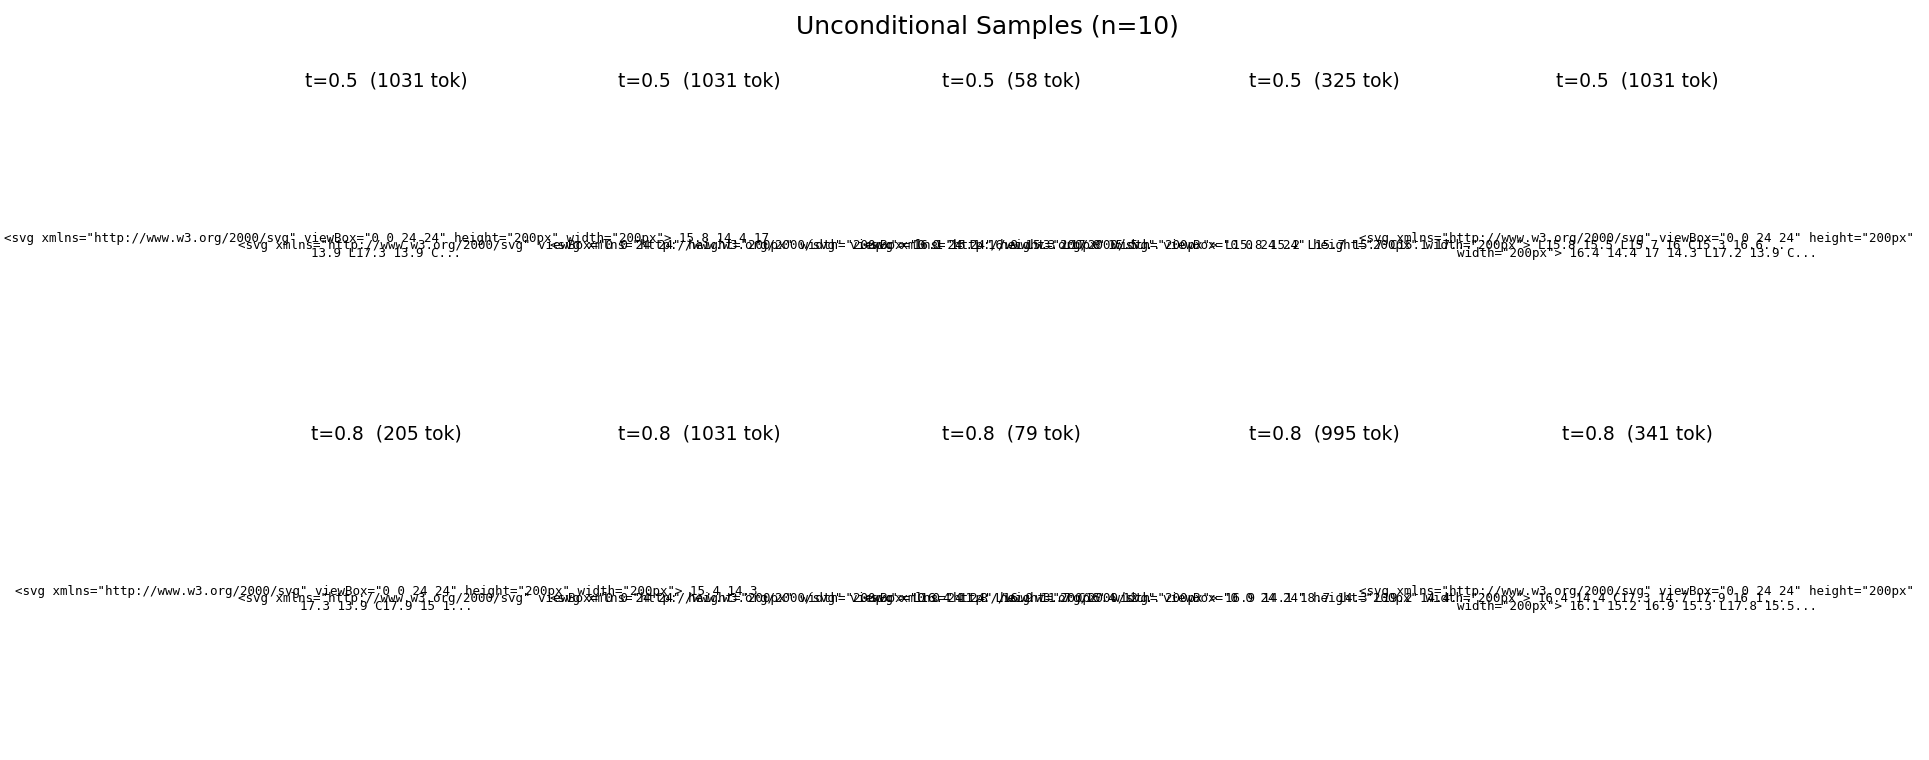


=== samples_temperature_comparison.png ===


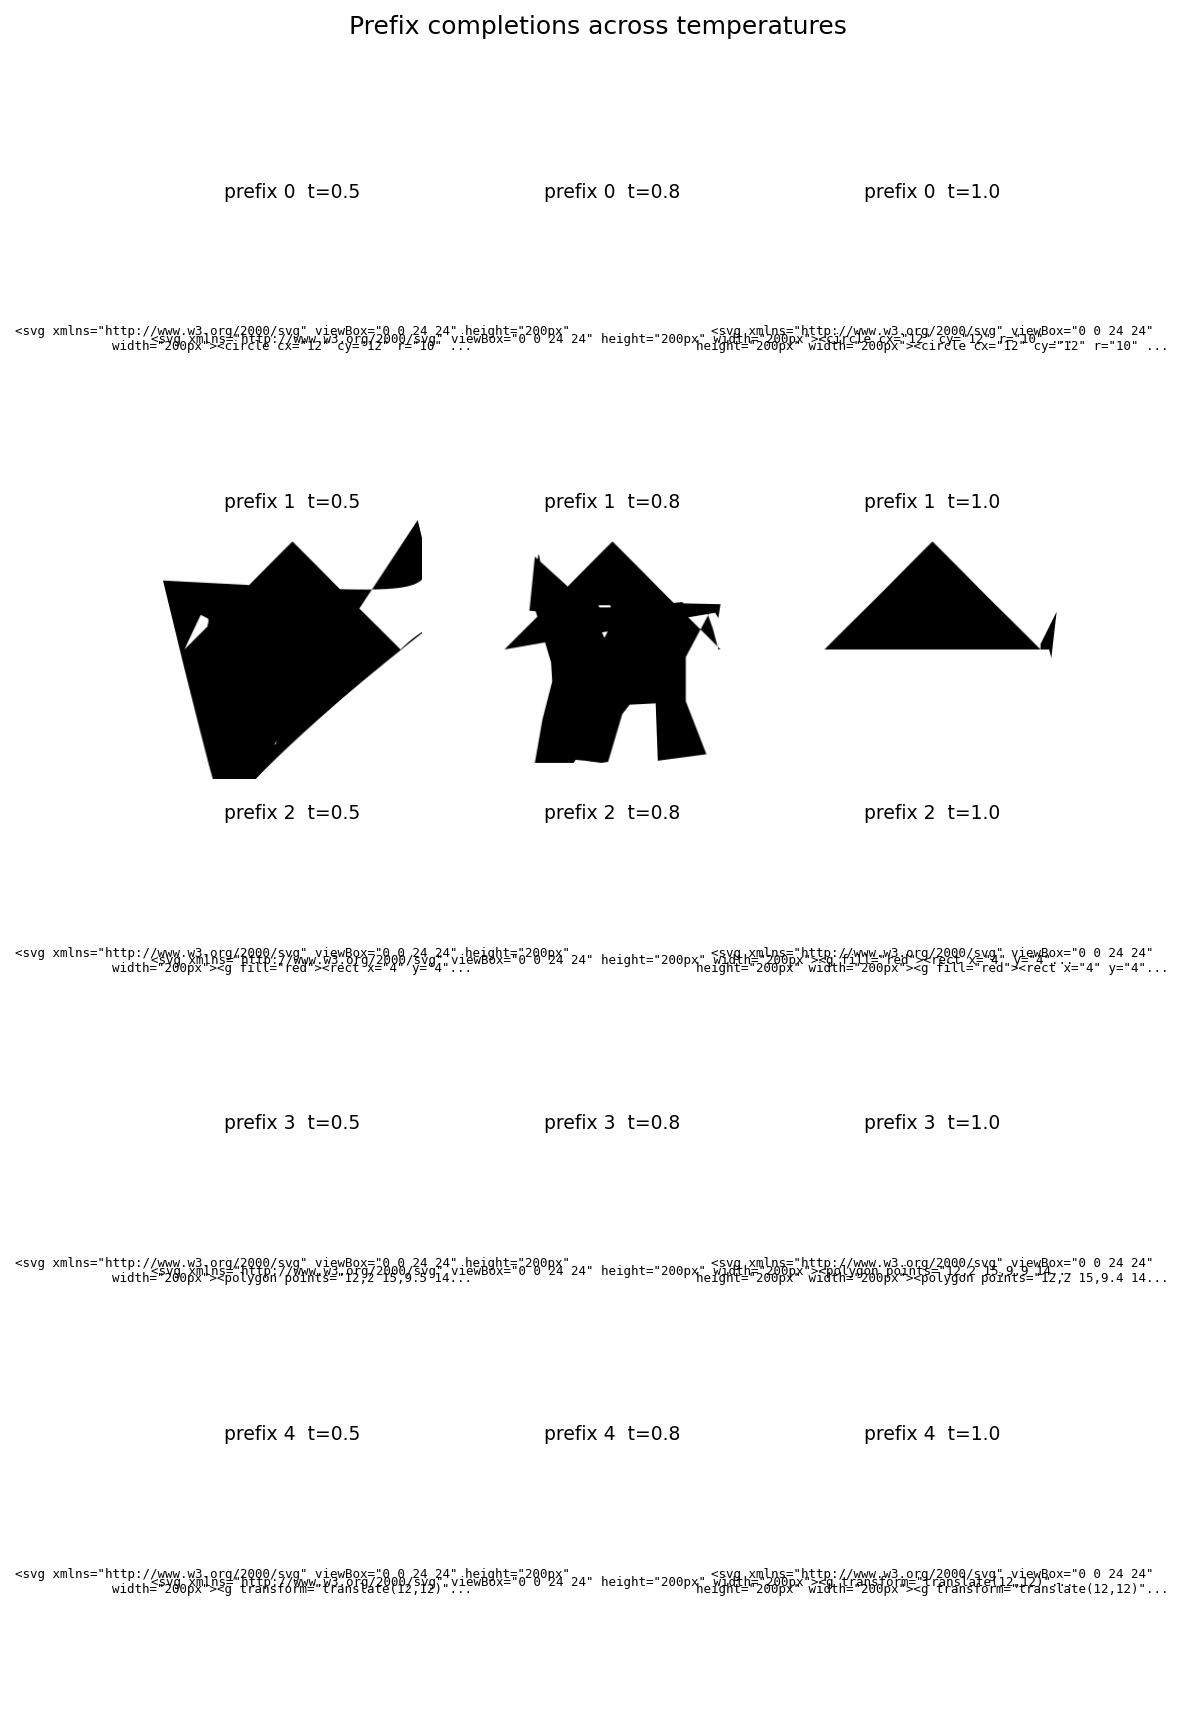


=== samples_prefix_completion.png ===


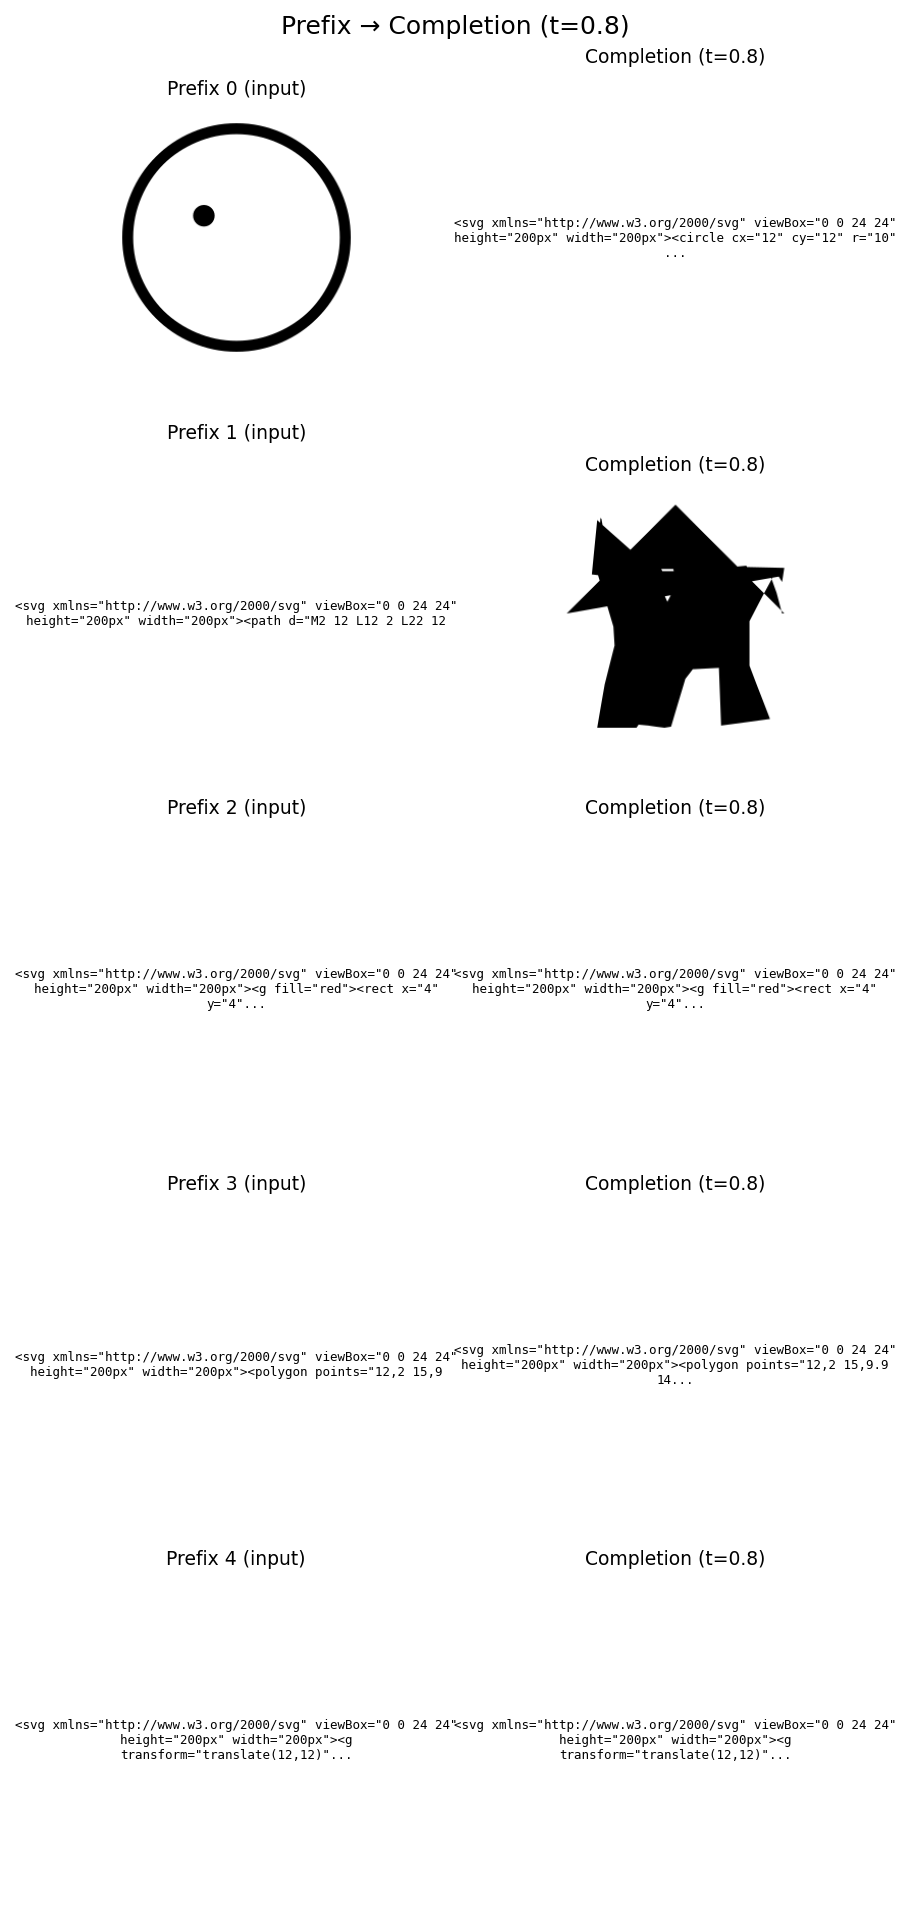

In [11]:
from IPython.display import Image, display
import os

for fname in ['samples_unconditional_grid.png',
              'samples_temperature_comparison.png',
              'samples_prefix_completion.png']:
    p = os.path.join('outputs/plots', fname)
    print(f'\n=== {fname} ===')
    if os.path.exists(p):
        display(Image(filename=p))
    else:
        print(f'  MISSING: {p}')

import json

m = json.load(open('outputs/logs/evaluation_metrics_extended.json'))
print('=== Extended XL Evaluation ===')
print(f"uncond  xml_valid:    {m['unconditional']['rates']['xml_valid_rate']*100:.1f}%")
print(f"uncond  renderable:   {m['unconditional']['rates']['svg_renderable_rate']*100:.1f}%")
print(f"prefix  xml_valid:    {m['prefix']['rates']['xml_valid_rate']*100:.1f}%")
print(f"prefix  renderable:   {m['prefix']['rates']['svg_renderable_rate']*100:.1f}%")
print(f"combined renderable:  {m['combined']['rates']['svg_renderable_rate']*100:.1f}%")
if 'perplexity' in m:
    print(f"perplexity:          {m['perplexity']['perplexity']:.2f}")
    print(f"mean CE:             {m['perplexity']['mean_cross_entropy']:.4f}")


In [ ]:
import json
m = json.load(open('outputs/logs/evaluation_metrics.json'))
print('uncond:', m['unconditional']['rates'])
print('prefix:', m['prefix']['rates'])
print('combined:', m['combined']['rates'])
print('ppl:', m['perplexity'])

uncond: {'xml_valid_rate': 0.0, 'has_svg_root_rate': 0.0, 'tags_closed_rate': 0.0, 'svg_renderable_rate': 0.0}
prefix: {'xml_valid_rate': 0.2, 'has_svg_root_rate': 0.2, 'tags_closed_rate': 0.2, 'svg_renderable_rate': 0.2}
combined: {'xml_valid_rate': 0.1, 'has_svg_root_rate': 0.1, 'tags_closed_rate': 0.1, 'svg_renderable_rate': 0.1}
ppl: {'mean_cross_entropy': 3.104926441533589, 'perplexity': 22.3075780036956, 'n_tokens_scored': 1340416}


In [ ]:
import numpy as np, sys
sys.path.insert(0, '/content/svg-scaling-laws')
from src.tokenizer_utils import load_tokenizer

arr = np.memmap('outputs/data/binary/train.bin', dtype=np.uint16, mode='r')
tok = load_tokenizer('outputs/tokenizer')

# Show the first 5 SVG headers from training
bos_positions = []
for i in range(min(len(arr), 100000)):
    if arr[i] == 1:  # BOS
        bos_positions.append(i)
        if len(bos_positions) >= 5:
            break

for p in bos_positions:
    text = tok.decode(list(arr[p:p+25].tolist()), skip_special_tokens=False)
    print(repr(text[:120]))


'<BOS><svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" height="200px" width="200px"><path fill="none" stroke="'
'<BOS><svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" height="200px" width="200px"><path fill="none" stroke="'
'<BOS><svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" height="200px" width="200px"><path fill="none" stroke="'
'<BOS><svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" height="200px" width="200px"><path fill="none" stroke="'
'<BOS><svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" height="200px" width="200px"><path fill="none" stroke="'


In [12]:
!head -c 350 outputs/samples/prefix/prefix0_t0.5.svg
print()
!head -c 350 outputs/samples/prefix/prefix2_t0.5.svg




<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" height="200px" width="200px"><circle cx="12" cy="12" r="10" fill="none" stroke="black"/><circle cx="9" cy="10" r="1" fill="black"/> 16.1 14.4 17.1 14.1 19.3 14.9 20.5 15.3 22.3 16 23.6 17.3 25.8 18.4 27.5 L16.7 27.5"></path>
<path fill="none" stroke="black" stroke-width=".3" stroke-opacity
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" height="200px" width="200px"><g fill="red"><rect x="4" y="4" width="6" height="6"/> L15.8 15.3 15.6 15.7 15.8 16 16.1 16.6 16.8 C17.2 19.3 17.2 21.6 18.7 23.6 L19.8 23.8"></path></svg>